# Training on INCLUDE_50 Dataset

## Preprocessing Data

In [1]:
import pandas as pd
import numpy as np
import os

import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Flatten

from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm

In [2]:
# Checking whether the gpu is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        print("Using GPU:", gpus)

    except RuntimeError as e:
        print(e)

else:
    print("No GPU found.")

Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
train_data = pd.read_csv('Dataset/train.csv')
test_data = pd.read_csv('Dataset/test.csv')

train_data.sample(5)

,parent_label,label,video_path,include_50
2735,People,70. Grandmother,People/70. Grandmother/MVI_3793.mp4,False
1127,People,70. Grandmother,People/70. Grandmother/MVI_5109.mp4,False
1696,Days_and_Time,68. Tuesday,Days_and_Time/68. Tuesday/MVI_4595.mp4,False
686,Electronics,53. Fan,Electronics/53. Fan/MVI_4965.mp4,False
2781,Home,27. Dream,Home/27. Dream/MVI_4360.mp4,False


In [61]:
# Extracting labels and video paths for the videos that are from the include 50 dataset

labels = []
train_path_I50 = []

for i in range(len(train_data)):
    if train_data['include_50'][i] == True:
        labels.append(train_data['label'][i])
        train_path_I50.append("Dataset\\" + train_data['video_path'][i])

labels = pd.Series(labels).unique()
labels = pd.Series(labels).to_list()

train_path_I50 = pd.Series(train_path_I50)

# train_path_I50.sample(5), labels.sample(5)
labels[:5]

['1. loud', '19. House', '83. big large', '91. Priest', '23. Court']

In [ ]:
# Prining the graph for labels and the number of videos for each label in include 50 dataset


In [62]:
label_map = dict()

# Creating a dictionary of labels with their corresponding index 
for i in range(len(labels)):
    # Splitting Label from num
    split = labels[i].split(" ")
    
    # Joining the ramining str to make a full label name
    label = split[1:]
    label = " ".join(label)
        
    label_map[split[0]] = label

labels = list(label_map.values())
  
label_map    

{'1.': 'Dog',
 '19.': 'House',
 '83.': 'big large',
 '91.': 'new',
 '23.': 'Court',
 '16.': 'train ticket',
 '44.': 'Shoes',
 '35.': 'Bank',
 '55.': 'White',
 '14.': 'Election',
 '5.': 'Cow',
 '28.': 'Store or Shop',
 '2.': 'Death',
 '97.': 'dry',
 '78.': 'Year',
 '48.': 'Hello',
 '4.': 'Bird',
 '37.': 'Hat',
 '54.': 'Cell phone',
 '79.': 'short',
 '53.': 'Fan',
 '67.': 'Monday',
 '46.': 'you (plural)',
 '42.': 'T-Shirt',
 '61.': 'Summer',
 '47.': 'Red',
 '87.': 'hot',
 '64.': 'Fall',
 '40.': 'Paint',
 '86.': 'Time',
 '11.': 'Car',
 '51.': 'Good Morning',
 '84.': 'small little',
 '66.': 'Brother',
 '94.': 'good',
 '3.': 'happy',
 '77.': 'Boy',
 '34.': 'Pen'}

In [25]:
# Loading all the labeled videos in the dataset
X = []
y= []

for label in tqdm(labels):
    label_videos = os.listdir("MP_data/"+label)
    
    
    for video in label_videos:        
        res = np.load("MP_data/" + f"{label}/" + video,allow_pickle=True)
        X.append(res)
        y.append(labels.index(label))        

len(X),len(y)

        

  0%|          | 0/50 [00:00<?, ?it/s]

(675, 675)

In [26]:
# Bhai yha meine kya hi harkat kari thi gandi wali bhai agar meine har vedio ka input ek baar mein hi pahucha dunga toh kaise kaam banega sab vedio ke inputs ko alag lena hoga na bhai :))))))

# Padding the videos to make them of the same length

max_frames = max([len(video) for video in X])
max_frames

X = pad_sequences(X, maxlen=max_frames, padding='post', dtype='float32')

print(X.shape)


(675, 154, 1662)


In [ ]:
X= np.array(X)
y= np.array(y)
y = to_categorical(y)

X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                  test_size=0.2, 
                                                  random_state=42,
                                                  shuffle=True) 

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (540, 154, 1662)
X_val shape: (135, 154, 1662)
y_train shape: (540, 50)
y_val shape: (135, 50)


# Model

## Architecture

In [28]:
import keras

# input_shape = (154, 1662)
input_shape = X_train[0].shape #(154, 1662)
num_classes =  len(label_map.keys())#50


In [ ]:


INCLUDESEQ50_V2 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(128, activation='relu'),
        
        # Output layer
        Dense(num_classes, activation='softmax')
])

model = INCLUDESEQ50_V2

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build(input_shape=(input_shape))

model.summary()

SyntaxError: invalid syntax (881948439.py, line 7)

In [19]:
INCLUDE8_V3 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        # Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V3

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirectiona  (None, 154, 128)         884224    
 l)                                                              
                                                                 
 bidirectional_1 (Bidirectio  (None, 154, 256)         263168    
 nal)                                                            
                                                                 
 bidirectional_2 (Bidirectio  (None, 154, 128)         164352    
 nal)                                                            
                                                                 
 flatten (Flatten)           (None, 19712)             0         
                                                                 
 dense (Dense)               (None, 64)                1261632   
                                                        

In [67]:
#Experimenting with different dropout configurations
from tensorflow.keras.layers import Dropout
# from tensorflow.keras import regularizers


INCLUDE8_V4 = keras.Sequential([        
        Input(shape=input_shape),        

        # Bidirectional LSTM layers
        
        # Dropout(0.5),
        Bidirectional(LSTM(32, return_sequences=True)),
        # Dropout(0.5),
        Bidirectional(LSTM(64, return_sequences=True)),
        # Dropout(0.5),
        Bidirectional(LSTM(32, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Dropout(0.5),
        # Fully connected layer
        Dense(64, activation='relu'),
        # Dense(64, activation='relu',kernel_regularizer=regularizers.l2(0.001)),
        # Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V4

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_28 (Bidirecti  (None, 154, 64)          433920    
 onal)                                                           
                                                                 
 bidirectional_29 (Bidirecti  (None, 154, 128)         66048     
 onal)                                                           
                                                                 
 bidirectional_30 (Bidirecti  (None, 154, 64)          41216     
 onal)                                                           
                                                                 
 flatten_10 (Flatten)        (None, 9856)              0         
                                                                 
 dense_20 (Dense)            (None, 64)                630848    
                                                     

In [68]:
history = model.fit(X_train,
          y_train,
          validation_data=(X_val, y_val), 
          epochs=60)


Epoch 1/60
17/17 [==============================] - 10s 204ms/step - loss: 3.9375 - accuracy: 0.0185 - val_loss: 3.8386 - val_accuracy: 0.0370
Epoch 2/60
17/17 [==============================] - 2s 96ms/step - loss: 3.8236 - accuracy: 0.0333 - val_loss: 3.8180 - val_accuracy: 0.0370
Epoch 3/60
17/17 [==============================] - 2s 91ms/step - loss: 3.7879 - accuracy: 0.0481 - val_loss: 3.7778 - val_accuracy: 0.0222
Epoch 4/60
17/17 [==============================] - 2s 89ms/step - loss: 3.7288 - accuracy: 0.0630 - val_loss: 3.7814 - val_accuracy: 0.0296
Epoch 5/60
17/17 [==============================] - 2s 90ms/step - loss: 3.6920 - accuracy: 0.0648 - val_loss: 3.7629 - val_accuracy: 0.0222
Epoch 6/60
17/17 [==============================] - 1s 87ms/step - loss: 3.6339 - accuracy: 0.0556 - val_loss: 3.7597 - val_accuracy: 0.0370
Epoch 7/60
17/17 [==============================] - 1s 88ms/step - loss: 3.6090 - accuracy: 0.0667 - val_loss: 3.6890 - val_accuracy: 0.0593
Epoch 8/60


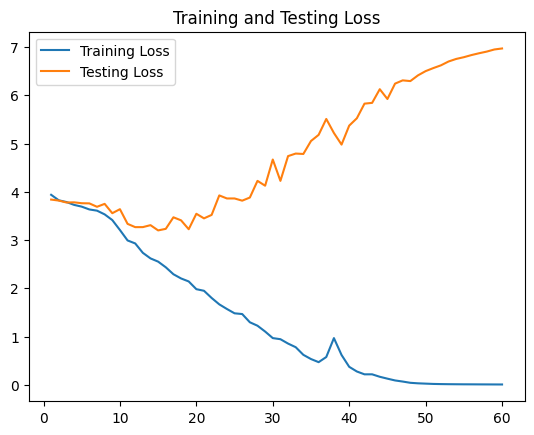

<Figure size 640x480 with 0 Axes>

In [69]:
from matplotlib import pyplot as plt

train_loss = history.history['loss']
eval_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.plot(epochs,train_loss,label = "Training Loss")
plt.plot(epochs,eval_loss,label = "Testing Loss")

plt.title("Training and Testing Loss")
plt.legend()
plt.figure()
plt.show();

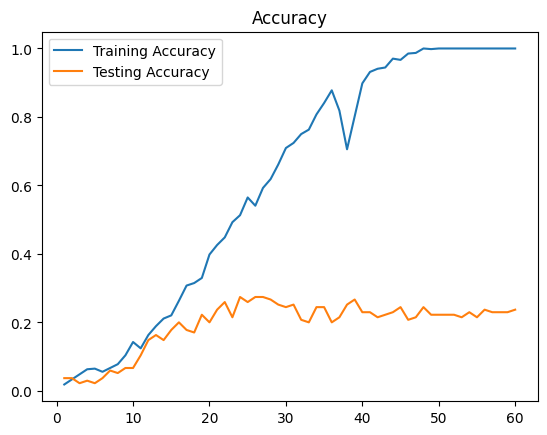

<Figure size 640x480 with 0 Axes>

In [70]:
train_acc = history.history['accuracy']
eval_acc = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs,train_acc,label = "Training Accuracy")
plt.plot(epochs,eval_acc,label = "Testing Accuracy")

plt.title("Accuracy")
plt.legend()
plt.figure()
plt.show();

In [36]:
# Predict probabilities for the test data
# probabilities = model.predict(X_val)
arr = np.load("MP_data\Bank\MVI_3336.npy")
print(arr.shape)
probabilities = model.predict(arr)

# Convert probabilities to class labels
predicted_classes = np.argmax(probabilities, axis=-1)

for i in range(10):
    print(f'Predicted: {label_map[predicted_classes[i]]}, True: {label_map[np.argmax(y_val[i])]}')


(63, 1662)


InvalidArgumentError: Graph execution error:

transpose expects a vector of size 2. But input(1) is a vector of size 3
	 [[{{node transpose}}]]
	 [[sequential_7/bidirectional_21/backward_lstm_21/PartitionedCall]] [Op:__inference_predict_function_184916]

In [ ]:
# model.save('INCLUDE_8_V1.h5')
try:
    os.mkdir("Model")
except:
    pass

keras.saving.save_model(model, "Model\INCLUDE_8_V3.keras")